# Visualization of Multivariate Data

<a target="_blank" href="https://colab.research.google.com/github/JunyoungB/statistical-computing-public/blob/main/ch3.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

## Panel Displays

### Scatterplot Matrix with Diagonal Densities

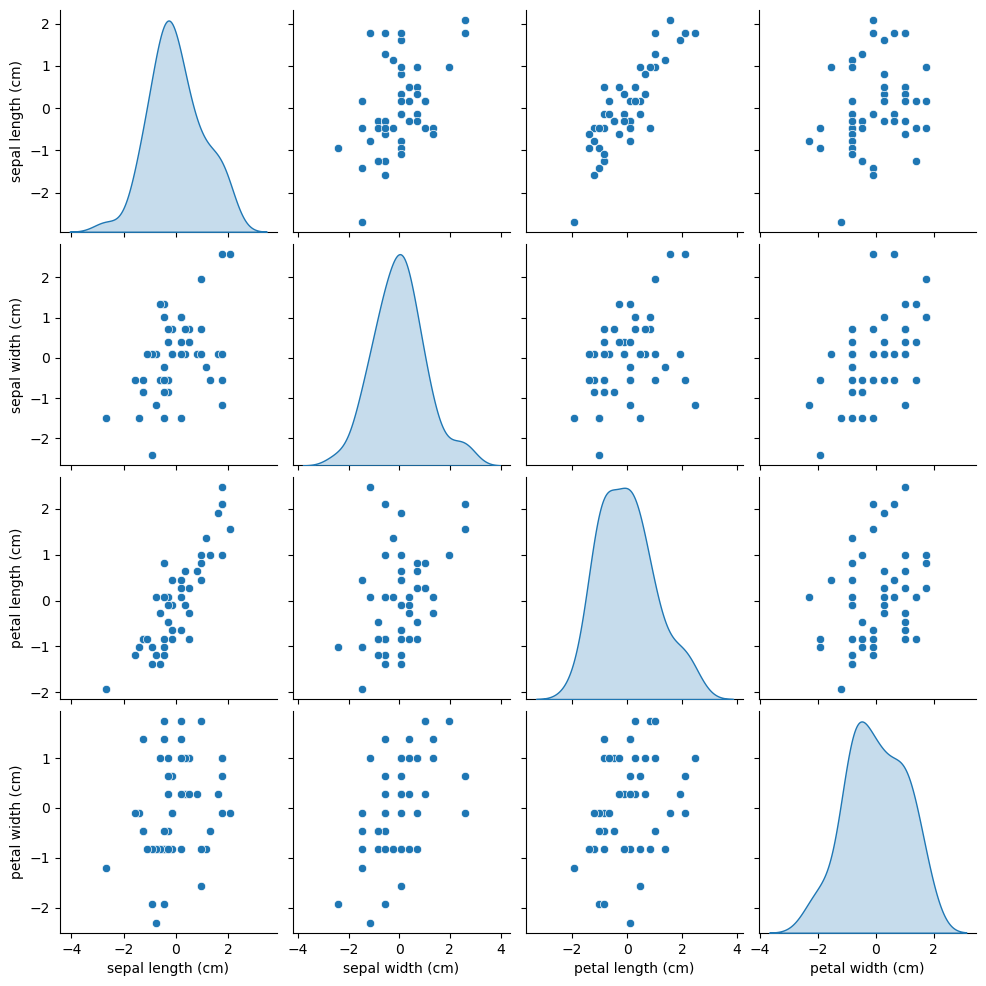

In [3]:
iris = load_iris(as_frame=True)
df = iris.frame.iloc[100:150, :4]
x = (df - df.mean()) / df.std(ddof=0)

g = sns.pairplot(x, diag_kind="kde")

plt.savefig("figs/3-1.png", dpi=160, bbox_inches='tight')
plt.show()

### Scatterplot Matrix by Species

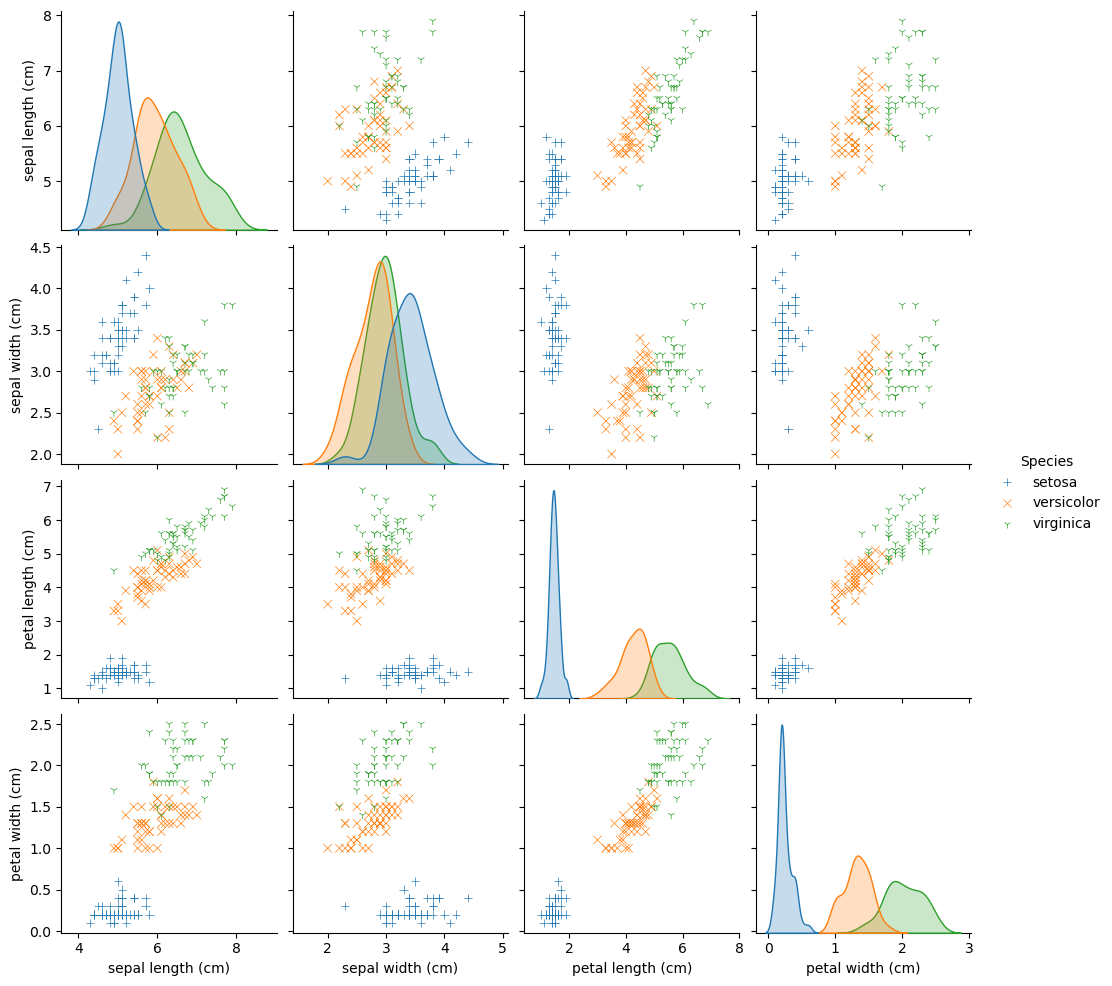

In [4]:
df = iris.frame.rename(columns={"target": "Species"})
df["Species"] = df["Species"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

sns.pairplot(
    df,
    vars=df.columns[:4],
    hue="Species",
    markers=["+", "x", "1"],   # 전부 line-art
)
plt.show()

## Correlation Plots

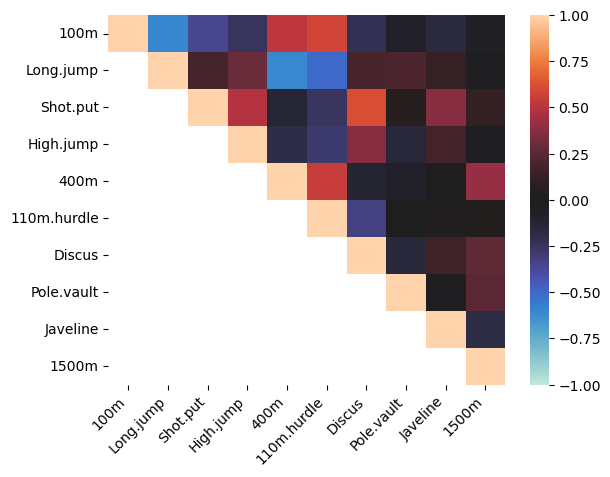

In [6]:
import pandas as pd
import numpy as np

decathlon = pd.read_csv("data/decathlon.csv", index_col=0)
decathlon
corr = decathlon.iloc[:, :10].corr()

mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)
ax = sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, center=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.show()

### Correlation Plot with Coefficients

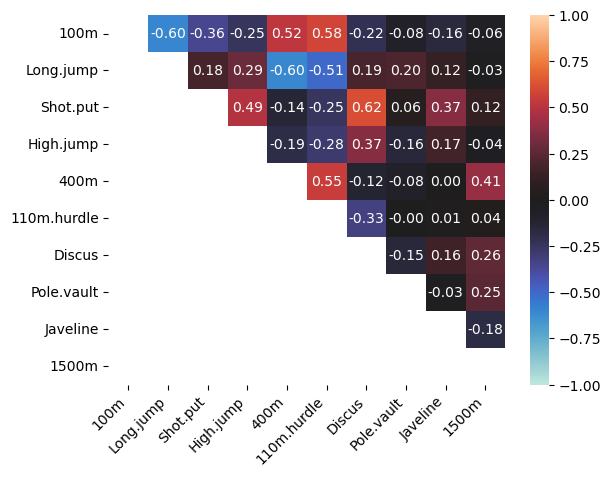

In [7]:
mask = np.tril(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f"
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.show()

## Surface Plots and 3D Scatter Plots

### Surface Plot

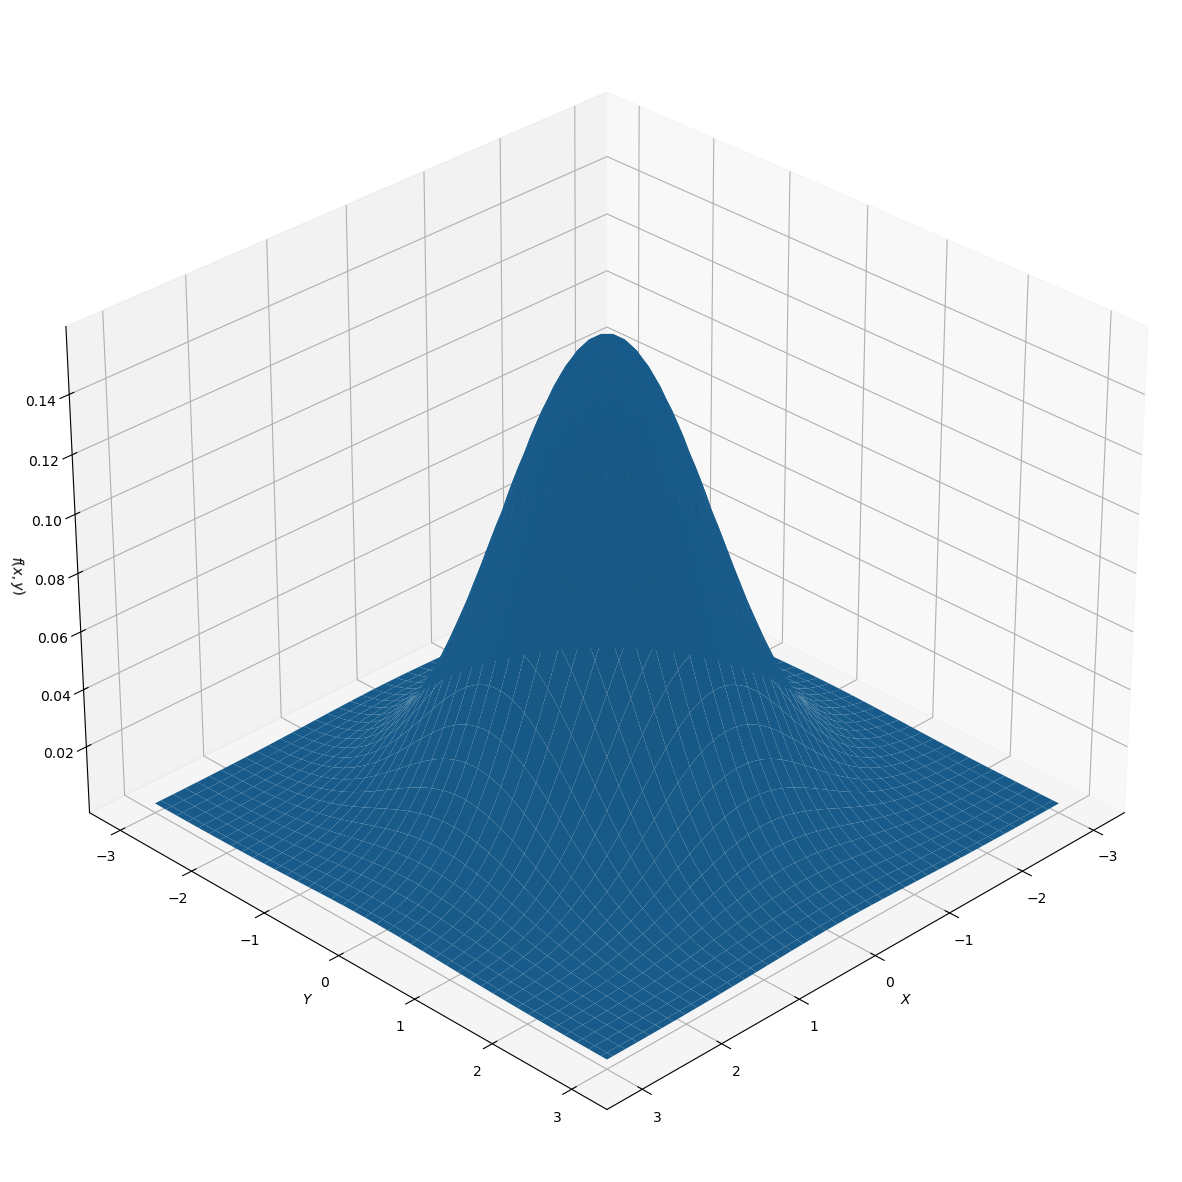

In [8]:
x = y = np.linspace(-3, 3, 80)          
X, Y = np.meshgrid(x, y)
Z = (1/(2*np.pi)) * np.exp(-0.5*(X**2 + Y**2))

fig = plt.figure(figsize=(15,24)) 
ax = fig.add_subplot(projection="3d")

ax.plot_surface(X, Y, Z)

ax.view_init(elev=30, azim=45)
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$Y$")
ax.set_zlabel(r"$f(x, y)$")   

plt.show()

### Wireframe Surface Plot

<Figure size 640x480 with 0 Axes>

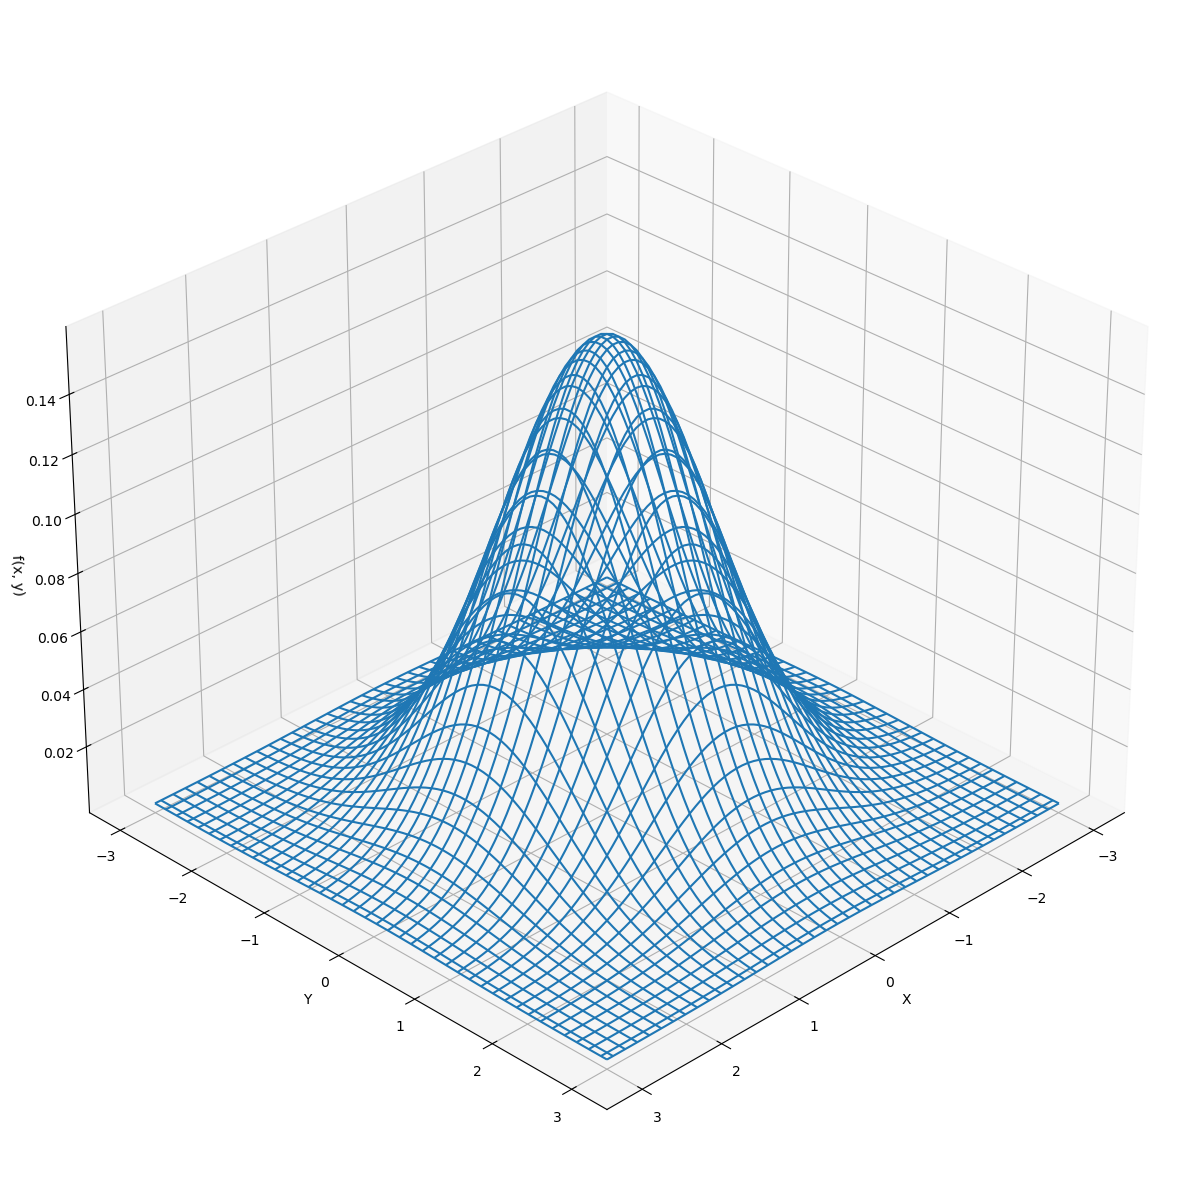

In [9]:
fig = plt.figure()
fig = plt.figure(figsize=(15,24)) 
ax = fig.add_subplot(projection="3d")
ax.plot_wireframe(X, Y, Z)

ax.view_init(elev=30, azim=45)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("f(x, y)")

plt.show()

### 3D Scatterplot

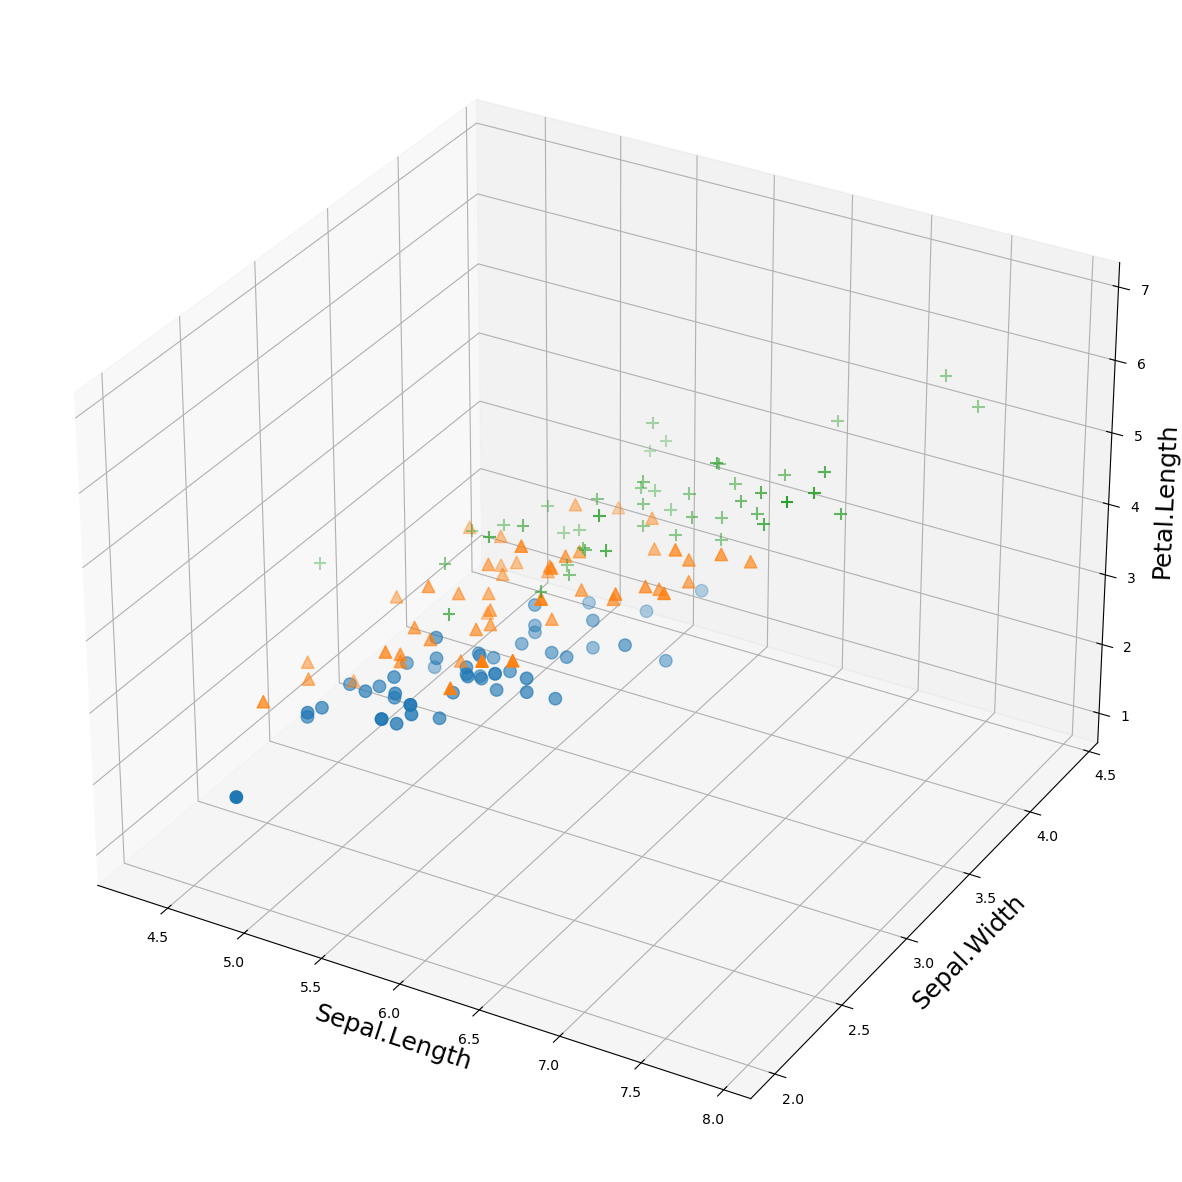

In [10]:
df = iris.frame
species = iris.target

X = df["sepal length (cm)"].to_numpy()
Y = df["sepal width (cm)"].to_numpy()
Z = df["petal length (cm)"].to_numpy()

markers = {0: "o", 1: "^", 2: "+"}

fig = plt.figure(figsize=(15,20))
ax = fig.add_subplot(projection="3d")

for k in [0, 1, 2]:
    idx = (species == k)
    ax.scatter(X[idx], Y[idx], Z[idx], marker=markers[k], s=80)

ax.set_xlabel("Sepal.Length", fontsize=18)
ax.set_ylabel("Sepal.Width",  fontsize=18)
ax.set_zlabel("Petal.Length", fontsize=18)

plt.show()

### Panel Display of 3D Scatterplots

In [11]:
def scatter_grouped(ax, x, y, z):
    for k in [0, 1, 2]:
        idx = (species == k)
        ax.scatter(x[idx], y[idx], z[idx], marker=markers[k])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

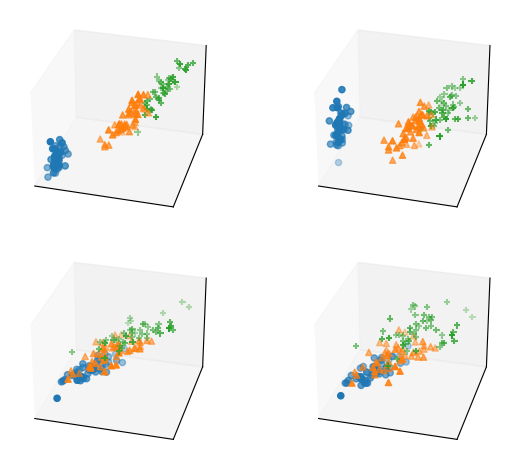

In [12]:
fig = plt.figure()

ax1 = fig.add_subplot(221, projection="3d")
scatter_grouped(ax1, df["petal length (cm)"], df["petal width (cm)"], df["sepal length (cm)"])
ax1.view_init(elev=30, azim=-75)

ax2 = fig.add_subplot(222, projection="3d")
scatter_grouped(ax2, df["petal length (cm)"], df["petal width (cm)"], df["sepal width (cm)"])
ax2.view_init(elev=30, azim=-75)

ax3 = fig.add_subplot(223, projection="3d")
scatter_grouped(ax3, df["sepal length (cm)"], df["sepal width (cm)"], df["petal length (cm)"])
ax3.view_init(elev=30, azim=-75)

ax4 = fig.add_subplot(224, projection="3d")
scatter_grouped(ax4, df["sepal length (cm)"], df["sepal width (cm)"], df["petal width (cm)"])
ax4.view_init(elev=30, azim=-75)

plt.tight_layout()
plt.savefig("figs/3-8.png", dpi=160, bbox_inches='tight')
plt.show()

## Contour Plots

### Contour Plot with Labels

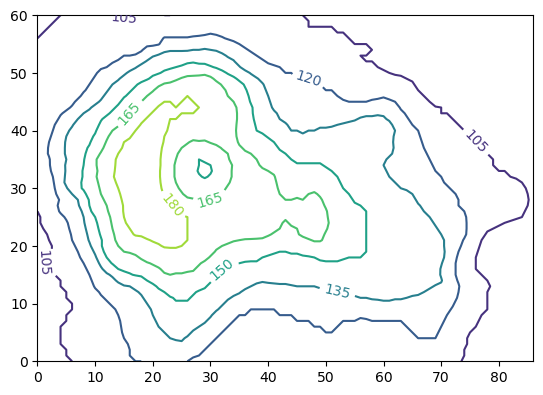

In [13]:
volcano = pd.read_csv("data/volcano.csv", index_col=0).T

plt.figure()
cs = plt.contour(volcano)
plt.clabel(cs, inline=True)

plt.gca().set_aspect("equal")
plt.savefig("figs/3-9.png", dpi=160, bbox_inches='tight')
plt.show()

### 3D Surface Plot

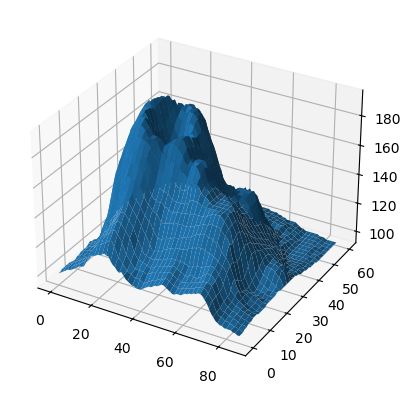

In [14]:
ny, nx = volcano.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, volcano)

plt.savefig("figs/3-10.png", dpi=160, bbox_inches='tight')
plt.show()

### Filled Contour Plots

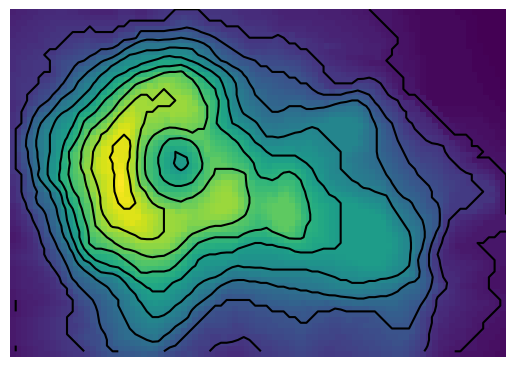

In [14]:
plt.figure()
plt.imshow(volcano, origin="lower", aspect="equal")
plt.axis("off")

levels = np.arange(100, 201, 10)
plt.contour(volcano, levels=levels, colors="black", origin="lower")

plt.savefig("figs/3-11.png", dpi=160, bbox_inches='tight')
plt.show()

### 2D Histogram with Hexagonal Bins

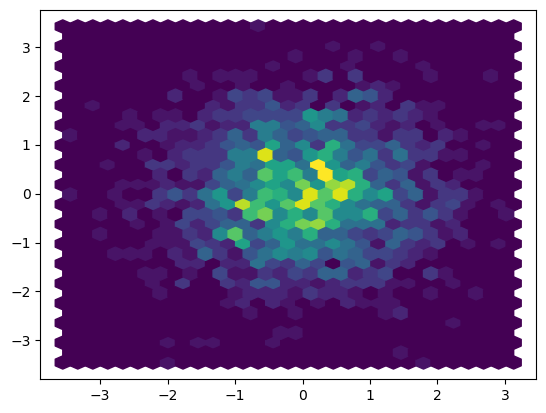

In [16]:
x = np.random.randn(2000, 2)

plt.figure()
plt.hexbin(x[:, 0], x[:, 1], gridsize=30)
plt.savefig("figs/3-12.png", dpi=160, bbox_inches='tight')
plt.show()

### 2D Histogram with Square Bins

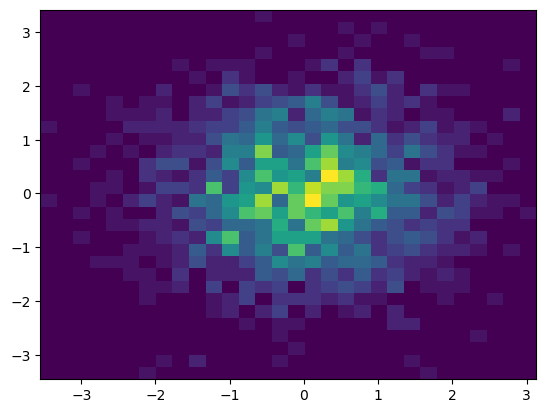

In [17]:
plt.figure()
plt.hist2d(x[:, 0], x[:, 1], bins=30)
plt.savefig("figs/3-13.png", dpi=160, bbox_inches='tight')
plt.show()

## Other 2D Representations

### Andrews Curves

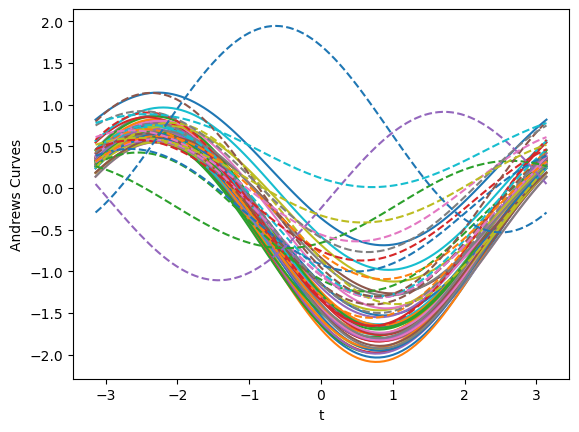

In [18]:
leaf = pd.read_csv("data/leafshape17.csv", index_col=0)
X = leaf[["bladelen", "petiole", "bladewid"]].to_numpy()

# scale each column to range [-1, 1]
mins = X.min(axis=0)
maxs = X.max(axis=0)
X_scaled = 2 * (X - mins) / (maxs - mins) - 1

t = np.linspace(-np.pi, np.pi, 101)

plt.figure()
for i in range(X_scaled.shape[0]):
    v = X_scaled[i, :]
    y = v[0]/np.sqrt(2) + v[1]*np.sin(t) + v[2]*np.cos(t)
    lty = "-" if leaf["arch"].iloc[i] == 0 else "--"
    plt.plot(t, y, lty)

plt.xlabel("t")
plt.ylabel("Andrews Curves")
plt.savefig("figs/3-14.png", dpi=160, bbox_inches='tight')
plt.show()

### Paralell Coordinate Plots

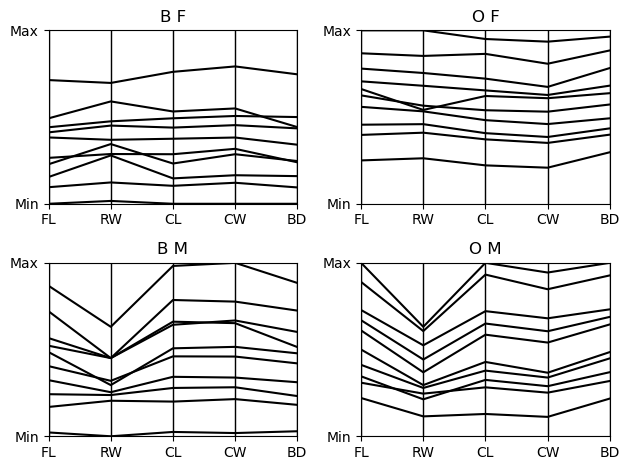

In [21]:
from pandas.plotting import parallel_coordinates

crabs = pd.read_csv("data/crabs.csv", index_col=0); x = crabs.iloc[4::5].copy() # 5,10,... 
vars = ["FL", "RW", "CL", "CW", "BD"]   
mins = x[vars].min(axis=0); maxs = x[vars].max(axis=0)
x[vars] = (x[vars] - mins) / (maxs - mins)

fig, axes = plt.subplots(2, 2)
sp_levels  = ["B", "O"]; sex_levels = ["F", "M"]
for i, sp in enumerate(sp_levels):
    for j, sex in enumerate(sex_levels):
        ax = axes[j, i] 
        sub = x[(x["sp"] == sp) & (x["sex"] == sex)][vars].copy()
        sub["grp"] = "all" #dummy

        parallel_coordinates(sub, "grp", ax=ax, color=["k"])
        ax.get_legend().remove()

        ax.set_title(f"{sp} {sex}")
        ax.set_ylim(0, 1); ax.set_yticks([0, 1]); ax.set_yticklabels(["Min", "Max"])
plt.tight_layout()
plt.savefig("figs/3-15.png", dpi=160, bbox_inches='tight')
plt.show()

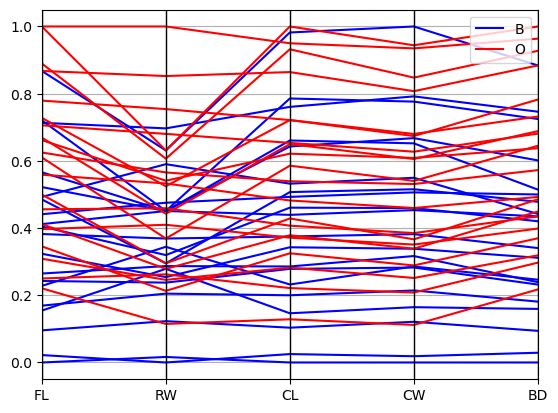

In [31]:
plt.figure()
parallel_coordinates(x, class_column='sp', cols=vars, color=['b','r'])
plt.show()

### Segment (Star) Plot

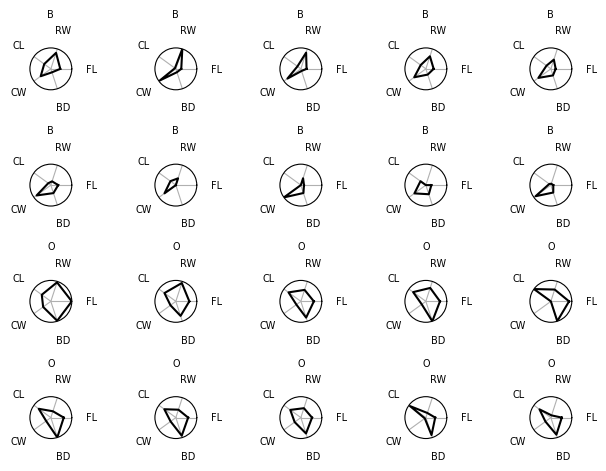

In [32]:
x = crabs.iloc[4::5].query("sex=='M'")
vars = ["FL", "RW", "CL", "CW", "BD"]
a = x["CW"] * x["CL"]
xs = x[vars].div(np.sqrt(a), axis=0); xs = (xs - xs.min()) / (xs.max() - xs.min())

n, nrow = len(xs), 4; ncol = int(np.ceil(n / nrow))
ang = np.linspace(0, 2*np.pi, len(vars), endpoint=False); ang = np.r_[ang, ang[0]]
fig, axes = plt.subplots(nrow, ncol, subplot_kw=dict(projection="polar"))
axes = np.array(axes).reshape(nrow, ncol)

for ax, k in zip(axes.ravel(), range(nrow*ncol)):
    ax.set(ylim=(0, 1)); ax.set_yticks([])
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(vars, fontsize=7)
    v = xs.iloc[k].to_numpy()
    ax.plot(ang, np.r_[v, v[0]], color="k")
    ax.set_title(str(x["sp"].iloc[k]), fontsize=7)

plt.tight_layout()
plt.savefig("figs/3-16.png", dpi=160, bbox_inches='tight')
plt.show()

## Principal Components Analysis

### Eigen Decomposition

In [44]:
scor = pd.read_csv("data/scor.csv")

X = (scor - scor.mean()) / scor.std()

# covariance of standardized data and eigen-decomposition
S = np.cov(X.to_numpy(), rowvar=False)
lam, P = np.linalg.eigh(S)           # ascending order
lam = lam[::-1]                      # descending eigenvalues
P = P[:, ::-1]                       # corresponding eigenvectors (loadings)

### Scree Plot (Explained Variance)

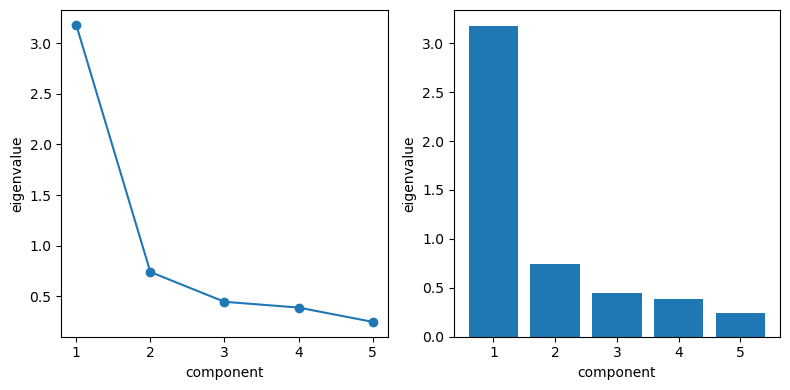

[[0.636196 0.147914 0.088993 0.077578 0.049318]
 [0.636196 0.78411  0.873103 0.950682 1.      ]]


In [45]:
prop = lam / lam.sum()
cum  = np.cumsum(prop)

# screeplot (eigenvalues)
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].plot(np.arange(1, len(lam) + 1), lam, marker="o")
axes[0].set_xlabel("component")
axes[0].set_ylabel("eigenvalue")

# barplot variant
axes[1].bar(np.arange(1, len(lam) + 1), lam)
axes[1].set_xlabel("component")
axes[1].set_ylabel("eigenvalue")

plt.tight_layout()
plt.savefig("figs/3-17.png", dpi=160, bbox_inches='tight')
plt.show()

tab = np.vstack([prop, cum])
print(np.round(tab, 6))

### Eigenvectors and Principal Components

In [46]:
Z = X.to_numpy() @ P     # scores (n x p)

print(Z.shape)
print(np.round(Z[:6, :], 6))   # first rows of PC score matrix

(88, 5)
[[-4.285041 -0.674102 -0.123589  0.793111  0.51438 ]
 [-4.541989  0.213312  0.23178   0.551606 -0.59619 ]
 [-4.10269  -0.275575 -0.530438  0.609686  0.027816]
 [-3.026846  0.149162  0.370215  0.159589  0.439505]
 [-2.882081  0.04408  -0.298886 -0.322574  0.147678]
 [-2.988775  0.681262 -0.262876  0.295033 -0.547545]]


In [47]:
from sklearn.decomposition import PCA

pca = PCA()
scores = pca.fit_transform(X.to_numpy())   # PC scores
loadings = pca.components_.T               # columns ~ eigenvectors (up to sign)

print("explained variance ratio:", np.round(pca.explained_variance_ratio_, 6))
print("cumulative:", np.round(np.cumsum(pca.explained_variance_ratio_), 6))

explained variance ratio: [0.636196 0.147914 0.088993 0.077578 0.049318]
cumulative: [0.636196 0.78411  0.873103 0.950682 1.      ]


In [48]:
loadings

array([[-0.39960451, -0.64545829,  0.62078249, -0.14578653,  0.13067218],
       [-0.43141908, -0.44150526, -0.70500628,  0.29813511,  0.18174786],
       [-0.50328158,  0.12906751, -0.03704901, -0.10859872, -0.84668939],
       [-0.4569938 ,  0.38790571, -0.13618182, -0.66625609,  0.42218853],
       [-0.43824437,  0.4704545 ,  0.31253342,  0.65891644,  0.23402226]])

In [49]:
P

array([[-0.39960451, -0.64545829, -0.62078249, -0.14578653,  0.13067218],
       [-0.43141908, -0.44150526,  0.70500628,  0.29813511,  0.18174786],
       [-0.50328158,  0.12906751,  0.03704901, -0.10859872, -0.84668939],
       [-0.4569938 ,  0.38790571,  0.13618182, -0.66625609,  0.42218853],
       [-0.43824437,  0.4704545 , -0.31253342,  0.65891644,  0.23402226]])

### PC Biplot

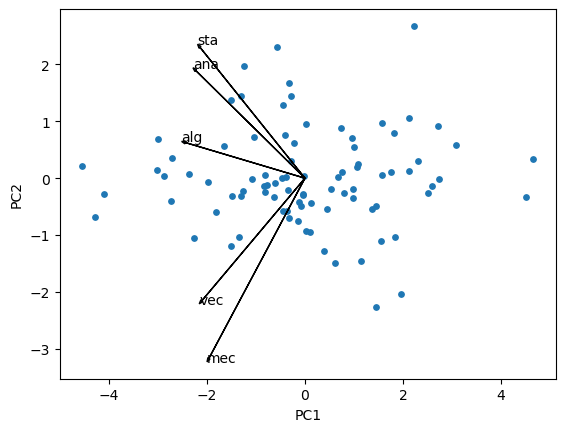

In [50]:
plt.figure()
plt.scatter(scores[:, 0], scores[:, 1], s=15)
cols = list(scor.columns)

scale = 5.0
for j in range(loadings.shape[0]):
    plt.arrow(0, 0, scale*loadings[j, 0], scale*loadings[j, 1], length_includes_head=True, head_width=0.05)
    plt.text(scale*loadings[j, 0], scale*loadings[j, 1], cols[j])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("figs/3-18.png", dpi=160, bbox_inches='tight')
plt.show()